In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import random
from math import radians, sin, cos, sqrt, atan2

Text(0, 0.5, 'Latitude')

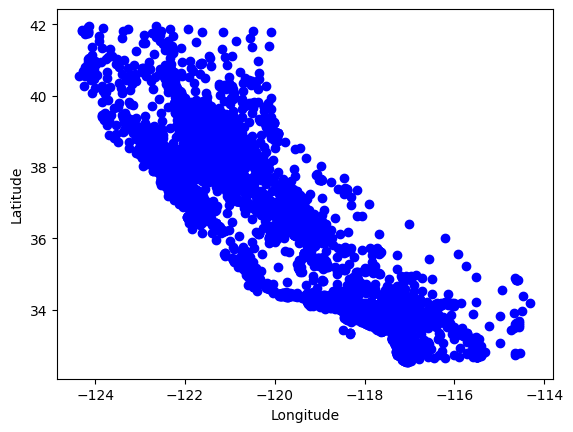

In [5]:
df = pd.read_excel('/Users/kevintruong/Downloads/california_housing_data.xlsx') 

#Extract the longitude and latitude columns from the original excel dataframe
latitude = pd.read_excel('/Users/kevintruong/Downloads/california_housing_data.xlsx', usecols = "H")
longitude = pd.read_excel('/Users/kevintruong/Downloads/california_housing_data.xlsx', usecols = "I")

#Put the columns into a list 
x_coords = [longitude]
y_coords = [latitude]

#Plot the data into a scatter graph to help visualise where all the nodes are.
plt.scatter(x_coords, y_coords, color="blue")   
plt.xlabel("Longitude")
plt.ylabel("Latitude")

In [6]:
#Extract the "Longitude" and "Latitude" column from the dataframe and assign to variable "lat_lon"
lat_lon = df[["Latitude","Longitude"]]

#Turn the lat_lon varaible into an array
coords = lat_lon.to_numpy()
   
#Use haversine formula to help calculate the shortest distance between two longitude and latitude points
def haversine(lon1, lat1, lon2, lat2):
    radius = 6371.0  # Earth's radius in km

    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return radius * c

#Distance threshold to be classified as "neighbouring"
threshold_km = 10

#Create graph
G = nx.Graph()

# Add nodes to the graph
for i, (lon, lat) in enumerate(coords):
    G.add_node(i, pos=(lon, lat))

n = len(coords)

for i in range(n):
    for j in range(i + 1, n):
        lon1, lat1 = coords[i]
        lon2, lat2 = coords[j]

        dist = haversine(lon1, lat1, lon2, lat2)

        if dist <= threshold_km:
            G.add_edge(i, j)

#Creating a dictionary
node_to_cluster = {}
#Takes the node and the cluster they are in
for cluster_id, component in enumerate(nx.connected_components(G)):
    #Iterates through each node 
    for node in component:
        #Adds the node to a dictionary as the key and the cluster as the value
        node_to_cluster[node] = cluster_id

#Copies the orignal dataframe
lat_lon_clustured = lat_lon.copy().reset_index(drop=True)
#Adds "cluster" column to original dataframe
lat_lon_clustured["cluster"] = lat_lon_clustured.index.map(node_to_cluster)

#Prints the number of unique clusters
print(lat_lon_clustured["cluster"].nunique())

#Prints the original dataframe with the cluster column added 
print(lat_lon_clustured)


260
       Latitude  Longitude  cluster
0         37.88    -122.23        0
1         37.86    -122.22        0
2         37.85    -122.24        0
3         37.85    -122.25        0
4         37.85    -122.25        0
...         ...        ...      ...
20635     39.48    -121.09        0
20636     39.49    -121.21        0
20637     39.43    -121.22        0
20638     39.43    -121.32        0
20639     39.37    -121.24        0

[20640 rows x 3 columns]


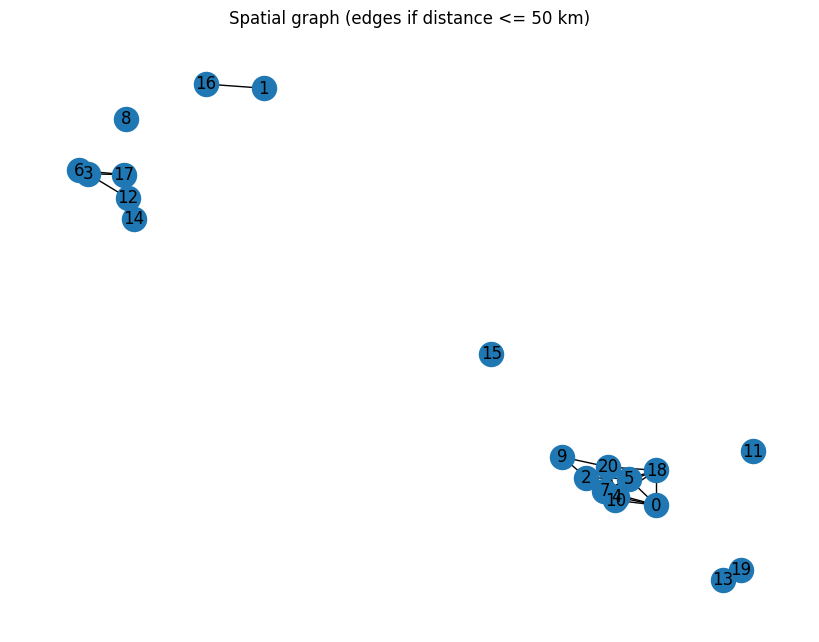

In [11]:
#Sample 0.1% of the data from the original dataframe 
test = df.sample(frac=0.001, random_state=2)

#Take the longitude and latitude column from the sample and turn it into a numpy array
coords = test[["Longitude","Latitude"]].to_numpy()

#Distance threshold, used 50km to help visualise the edges between nodes.
threshold_km = 50

# Create graph
G = nx.Graph()

#Add nodes to the graph
for i, (lon, lat) in enumerate(coords):
    G.add_node(i, pos=(lon, lat))

#Add edges between nodes if within threshold
n = len(coords)
for i in range(n):
    for j in range(i + 1, n):
        lon1, lat1 = coords[i]
        lon2, lat2 = coords[j]
        dist = haversine(lon1, lat1, lon2, lat2)

        if dist <= threshold_km:
            G.add_edge(i, j, weight=dist)

#Draw the graph using geographic positions
pos = nx.get_node_attributes(G, 'pos')

plt.figure(figsize=(8, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=300
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Spatial graph (edges if distance <= {threshold_km} km)")
plt.show()